# 自己教師あり学習（SimCLR簡易版）

このノートブックでは、CIFAR-10で簡易的なSimCLR風の自己教師あり学習を行い、その後に線形評価（linear probing）とスクラッチ学習を比較します。

In [1]:
# 必要なライブラリ
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
import torch.nn.functional as F
import matplotlib.pyplot as plt
from matplotlib import font_manager
from PIL import Image

# 日本語フォント設定（利用可能なものを自動選択）
def set_japanese_font():
    candidates = [
        "IPAexGothic",
        "IPAGothic",
        "Noto Sans CJK JP",
        "Noto Sans JP",
        "TakaoGothic",
        "Yu Gothic",
        "Hiragino Sans",
    ]
    available = {f.name for f in font_manager.fontManager.ttflist}
    for name in candidates:
        if name in available:
            plt.rcParams["font.family"] = name
            break
    plt.rcParams["axes.unicode_minus"] = False

set_japanese_font()

# 再現性
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

# デバイス
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cuda


## 1. データ準備（CIFAR-10）

自己教師あり学習用の強い拡張を使います。学習時間短縮のためにサブセットで実行します。

In [2]:
data_root = "../1.AutoEncoder/data"

# SimCLR用の拡張
simclr_tf = transforms.Compose([
    transforms.RandomResizedCrop(32, scale=(0.6, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.4, 0.4, 0.4, 0.1),
    transforms.RandomGrayscale(p=0.2),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

# 線形評価用の標準拡張
train_tf = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

test_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

full_train = datasets.CIFAR10(root=data_root, train=True, download=False)
full_test = datasets.CIFAR10(root=data_root, train=False, download=False, transform=test_tf)

# サブセット（速度優先）
subset_size = 10000
indices = np.random.choice(len(full_train), subset_size, replace=False)

class TwoViewCIFAR10(datasets.CIFAR10):
    def __init__(self, root, train, transform):
        super().__init__(root=root, train=train, download=False, transform=transform)

    def __getitem__(self, index):
        img, _ = self.data[index], self.targets[index]
        img = transforms.ToPILImage()(img)
        v1 = simclr_tf(img)
        v2 = simclr_tf(img)
        return v1, v2

ssl_dataset = TwoViewCIFAR10(root=data_root, train=True, transform=simclr_tf)
ssl_dataset = Subset(ssl_dataset, indices)

train_dataset = datasets.CIFAR10(root=data_root, train=True, download=False, transform=train_tf)
train_dataset = Subset(train_dataset, indices)

ssl_loader = DataLoader(ssl_dataset, batch_size=256, shuffle=True, num_workers=2, drop_last=True)
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True, num_workers=2)
test_loader = DataLoader(full_test, batch_size=256, shuffle=False, num_workers=2)

class_names = full_test.classes
print("classes:", class_names)

classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


## 2. SimCLR簡易モデルと損失

ResNet18の特徴に投影ヘッドを付け、NT-Xent損失で学習します。

In [3]:
class SimCLR(nn.Module):
    def __init__(self, base_model, proj_dim=128):
        super().__init__()
        self.encoder = nn.Sequential(*list(base_model.children())[:-1])
        feat_dim = base_model.fc.in_features
        self.projector = nn.Sequential(
            nn.Linear(feat_dim, feat_dim),
            nn.ReLU(inplace=True),
            nn.Linear(feat_dim, proj_dim),
        )

    def forward(self, x):
        h = self.encoder(x).squeeze(-1).squeeze(-1)
        z = self.projector(h)
        z = F.normalize(z, dim=1)
        return z


def nt_xent_loss(z1, z2, temperature=0.5):
    # z1, z2: [N, D]（正規化済み）
    logits = torch.mm(z1, z2.t()) / temperature
    labels = torch.arange(z1.size(0), device=z1.device)
    loss_a = F.cross_entropy(logits, labels)
    loss_b = F.cross_entropy(logits.t(), labels)
    return 0.5 * (loss_a + loss_b)


base = models.resnet18(weights=None)
ssl_model = SimCLR(base_model=base, proj_dim=128)

# 4GPUを想定してDataParallelを利用
if torch.cuda.is_available():
    gpu_count = torch.cuda.device_count()
    if gpu_count >= 2:
        ssl_model = nn.DataParallel(ssl_model, device_ids=list(range(min(4, gpu_count))))

ssl_model = ssl_model.to(device)
print(ssl_model)

DataParallel(
  (module): SimCLR(
    (encoder): Sequential(
      (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (4): Sequential(
        (0): BasicBlock(
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu): ReLU(inplace=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (1): BasicBlock(
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e

## 3. 自己教師あり学習（SimCLR）

少数エポックで事前学習を行います。

In [4]:
ssl_optimizer = optim.Adam(ssl_model.parameters(), lr=1e-3)
ssl_epochs = 2

for epoch in range(ssl_epochs):
    ssl_model.train()
    running_loss = 0.0
    for v1, v2 in ssl_loader:
        v1 = v1.to(device)
        v2 = v2.to(device)

        ssl_optimizer.zero_grad()
        z1 = ssl_model(v1)
        z2 = ssl_model(v2)
        loss = nt_xent_loss(z1, z2, temperature=0.5)
        loss.backward()
        ssl_optimizer.step()

        running_loss += loss.item() * v1.size(0)

    epoch_loss = running_loss / len(ssl_loader.dataset)
    print(f"ssl epoch {epoch+1}/{ssl_epochs} loss: {epoch_loss:.4f}")

ssl epoch 1/2 loss: 4.5370
ssl epoch 2/2 loss: 4.2682


## 4. 線形評価とスクラッチ比較

自己教師ありの特徴を固定して線形分類を学習し、スクラッチ学習と比較します。

In [5]:
def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            labels = labels.to(device)
            logits = model(imgs)
            preds = torch.argmax(logits, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return correct / total


# 4-1. 線形評価（encoder固定）
encoder = ssl_model.module.encoder if isinstance(ssl_model, nn.DataParallel) else ssl_model.encoder
for p in encoder.parameters():
    p.requires_grad = False

linear_head = nn.Linear(512, 10).to(device)
lin_optimizer = optim.Adam(linear_head.parameters(), lr=1e-3)
lin_epochs = 2

for epoch in range(lin_epochs):
    linear_head.train()
    running_loss = 0.0
    for imgs, labels in train_loader:
        imgs = imgs.to(device)
        labels = labels.to(device)

        with torch.no_grad():
            feats = encoder(imgs).squeeze(-1).squeeze(-1)

        lin_optimizer.zero_grad()
        logits = linear_head(feats)
        loss = F.cross_entropy(logits, labels)
        loss.backward()
        lin_optimizer.step()

        running_loss += loss.item() * imgs.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    print(f"linear epoch {epoch+1}/{lin_epochs} loss: {epoch_loss:.4f}")

# 線形評価の精度
class LinearEvalModel(nn.Module):
    def __init__(self, encoder, head):
        super().__init__()
        self.encoder = encoder
        self.head = head

    def forward(self, x):
        feats = self.encoder(x).squeeze(-1).squeeze(-1)
        return self.head(feats)

linear_model = LinearEvalModel(encoder, linear_head).to(device)
acc_linear = evaluate(linear_model, test_loader)
print(f"linear eval acc: {acc_linear:.4f}")

# 4-2. スクラッチ学習
scratch = models.resnet18(weights=None)
scratch.fc = nn.Linear(scratch.fc.in_features, 10)

# 4GPUを想定してDataParallelを利用
if torch.cuda.is_available():
    gpu_count = torch.cuda.device_count()
    if gpu_count >= 2:
        scratch = nn.DataParallel(scratch, device_ids=list(range(min(4, gpu_count))))

scratch = scratch.to(device)

scr_optimizer = optim.Adam(scratch.parameters(), lr=1e-3)
scr_epochs = 2

for epoch in range(scr_epochs):
    scratch.train()
    running_loss = 0.0
    for imgs, labels in train_loader:
        imgs = imgs.to(device)
        labels = labels.to(device)

        scr_optimizer.zero_grad()
        logits = scratch(imgs)
        loss = F.cross_entropy(logits, labels)
        loss.backward()
        scr_optimizer.step()

        running_loss += loss.item() * imgs.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    print(f"scratch epoch {epoch+1}/{scr_epochs} loss: {epoch_loss:.4f}")

acc_scratch = evaluate(scratch, test_loader)
print(f"scratch acc: {acc_scratch:.4f}")

linear epoch 1/2 loss: 1.9651
linear epoch 2/2 loss: 1.8387
linear eval acc: 0.3411
scratch epoch 1/2 loss: 1.8056
scratch epoch 2/2 loss: 1.4527
scratch acc: 0.4820


## 5. ImageNet-1K事前学習との比較

ImageNet-1Kで事前学習されたResNet18の特徴を固定し、線形評価で比較します。

In [6]:
# ImageNet-1K事前学習モデル
imagenet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
imagenet_encoder = nn.Sequential(*list(imagenet.children())[:-1]).to(device)
for p in imagenet_encoder.parameters():
    p.requires_grad = False

imagenet_head = nn.Linear(imagenet.fc.in_features, 10).to(device)
img_optimizer = optim.Adam(imagenet_head.parameters(), lr=1e-3)
img_epochs = 2

for epoch in range(img_epochs):
    imagenet_head.train()
    running_loss = 0.0
    for imgs, labels in train_loader:
        imgs = imgs.to(device)
        labels = labels.to(device)

        with torch.no_grad():
            feats = imagenet_encoder(imgs).squeeze(-1).squeeze(-1)

        img_optimizer.zero_grad()
        logits = imagenet_head(feats)
        loss = F.cross_entropy(logits, labels)
        loss.backward()
        img_optimizer.step()

        running_loss += loss.item() * imgs.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    print(f"imagenet linear epoch {epoch+1}/{img_epochs} loss: {epoch_loss:.4f}")

class ImageNetLinearModel(nn.Module):
    def __init__(self, encoder, head):
        super().__init__()
        self.encoder = encoder
        self.head = head

    def forward(self, x):
        feats = self.encoder(x).squeeze(-1).squeeze(-1)
        return self.head(feats)

imagenet_linear = ImageNetLinearModel(imagenet_encoder, imagenet_head).to(device)
acc_imagenet = evaluate(imagenet_linear, test_loader)
print(f"imagenet linear acc: {acc_imagenet:.4f}")

imagenet linear epoch 1/2 loss: 2.1907
imagenet linear epoch 2/2 loss: 1.8211
imagenet linear acc: 0.3810


## 6. test.pngでの分類比較

SimCLR（線形評価モデル）とImageNet-1K事前学習の線形モデルで比較します。

SimCLR top-5:
  horse: 0.4009
  frog: 0.2350
  deer: 0.1531
  ship: 0.0699
  airplane: 0.0578
ImageNet top-5:
  horse: 0.7532
  truck: 0.0826
  bird: 0.0484
  dog: 0.0364
  ship: 0.0299


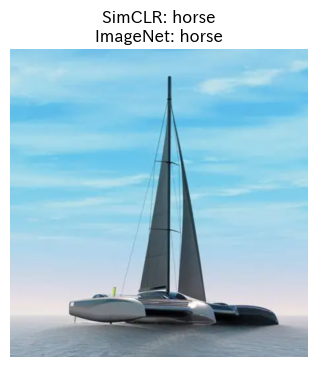

In [ ]:
import os
from PIL import Image

test_img_paths = ["test1.png", "test2.png", "test3.png"]
for test_img_path in test_img_paths:
    if not os.path.exists(test_img_path):
        raise FileNotFoundError(f"{test_img_path} が見つかりません")

for test_img_path in test_img_paths:
    img = Image.open(test_img_path).convert("RGB")
    x = test_tf(img).unsqueeze(0).to(device)

    # SimCLR線形評価モデル
    linear_model.eval()
    with torch.no_grad():
        logits_simclr = linear_model(x)
        probs_simclr = torch.softmax(logits_simclr, dim=1)
        top_probs_simclr, top_idxs_simclr = torch.topk(probs_simclr, k=5, dim=1)

    # ImageNet-1K線形モデル
    imagenet_linear.eval()
    with torch.no_grad():
        logits_imagenet = imagenet_linear(x)
        probs_imagenet = torch.softmax(logits_imagenet, dim=1)
        top_probs_imagenet, top_idxs_imagenet = torch.topk(probs_imagenet, k=5, dim=1)

    print(f"\n== {test_img_path} ==")
    print("SimCLR top-5:")
    for p, idx in zip(top_probs_simclr[0].tolist(), top_idxs_simclr[0].tolist()):
        print(f"  {class_names[idx]}: {p:.4f}")

    print("ImageNet top-5:")
    for p, idx in zip(top_probs_imagenet[0].tolist(), top_idxs_imagenet[0].tolist()):
        print(f"  {class_names[idx]}: {p:.4f}")

    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.axis("off")
    plt.title(
        f"{test_img_path}\n"
        f"SimCLR: {class_names[top_idxs_simclr[0,0]]}\n"
        f"ImageNet: {class_names[top_idxs_imagenet[0,0]]}"
    )
    plt.show()